In [6]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import ecc_vr 
importlib.reload(ecc_vr)
importlib.reload(ecc_vr.metrics)
import ecc_vr as vr

from pathlib import Path
import sys

week5_path = Path.cwd().parent / "Week5"
if str(week5_path) not in sys.path:
    sys.path.append(str(week5_path))

from Sphere_Ellipsoid_Utils import (
    unif_hypersphere,
    unif_hyperellipsoid,
    unit_ball_volume,
    scale_axes_target_volume,
    simulate_edge_curves_kde,
    plot_sphere_ellipsoid_results,
    simulate_triangle_curves_kde,
    non_unif_hyperellipsoid,
)


from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [7]:
def sphere_vs_ellipsoid_concat_curve_classifier_kde(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        h: float = 0.15,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        seed3: int = 44,
        seed4: int = 45,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    edge_curves_sphere = simulate_edge_curves_kde(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed = seed1,
    )

    triangle_curves_sphere = simulate_triangle_curves_kde(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples = n_resamples,
        t_grid = t_grid,
        h = h,
        seed = seed3
    )
    
    edge_curves_ellipsoid = simulate_edge_curves_kde(
        point_cloud_sampler=lambda s: non_unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed=seed2,
    )

    triangle_curves_ellipsoid = simulate_triangle_curves_kde(
        point_cloud_sampler=lambda s: non_unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed=seed4,
    )

    curves_sphere = np.hstack([edge_curves_sphere, triangle_curves_sphere])
    curves_ellipsoid = np.hstack([edge_curves_ellipsoid, triangle_curves_ellipsoid])

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

def plot_sphere_ellipsoid_concat_results(result):
    t_grid = result["t_grid"]
    m = len(t_grid)

    curves_sphere = result["curves_sphere"]
    curves_ellipsoid = result["curves_ellipsoid"]

    sphere_edge = curves_sphere[:, :m]
    sphere_triangle = curves_sphere[:, m:]

    ellipsoid_edge = curves_ellipsoid[:, :m]
    ellipsoid_triangle = curves_ellipsoid[:, m:]

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    mean_se = sphere_edge.mean(axis=0)
    sd_se = sphere_edge.std(axis=0, ddof=1)
    mean_ee = ellipsoid_edge.mean(axis=0)
    sd_ee = ellipsoid_edge.std(axis=0, ddof=1)

    ax[0].plot(t_grid, mean_se, lw=2, label="Sphere Edge Mean")
    ax[0].fill_between(t_grid, mean_se - sd_se, mean_se + sd_se, alpha=0.2)
    ax[0].plot(t_grid, mean_ee, lw=2, label="Ellipsoid Edge Mean")
    ax[0].fill_between(t_grid, mean_ee - sd_ee, mean_ee + sd_ee, alpha=0.2)
    ax[0].set_title("Edge Curves")
    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Count")
    ax[0].legend()

    mean_st = sphere_triangle.mean(axis=0)
    sd_st = sphere_triangle.std(axis=0, ddof=1)
    mean_et = ellipsoid_triangle.mean(axis=0)
    sd_et = ellipsoid_triangle.std(axis=0, ddof=1)

    ax[1].plot(t_grid, mean_st, lw=2, label="Sphere Triangle Mean")
    ax[1].fill_between(t_grid, mean_st - sd_st, mean_st + sd_st, alpha=0.2)
    ax[1].plot(t_grid, mean_et, lw=2, label="Ellipsoid Triangle Mean")
    ax[1].fill_between(t_grid, mean_et - sd_et, mean_et + sd_et, alpha=0.2)
    ax[1].set_title("Triangle Curves")
    ax[1].set_xlabel("t")
    ax[1].set_ylabel("Count")
    ax[1].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=["Sphere", "Ellipsoid"],
        cmap="Blues",
        ax=ax[2],
    )
    ax[2].set_title("Classifier Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print("Ambient dim:", result["ambient_dim"])
    print("Sphere radius:", result["sphere_radius"])
    print("Ellipsoid axes:", result["ellipsoid_axes"])



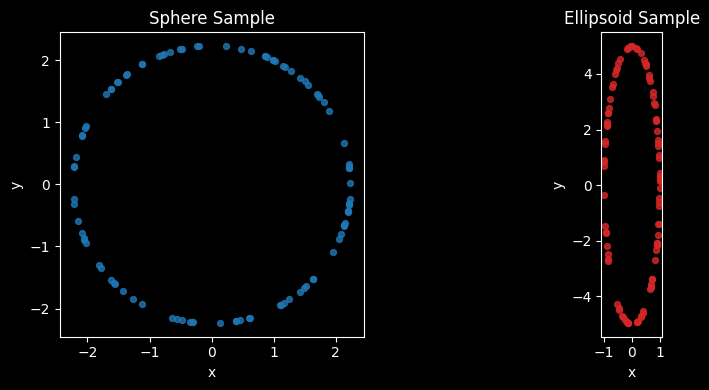

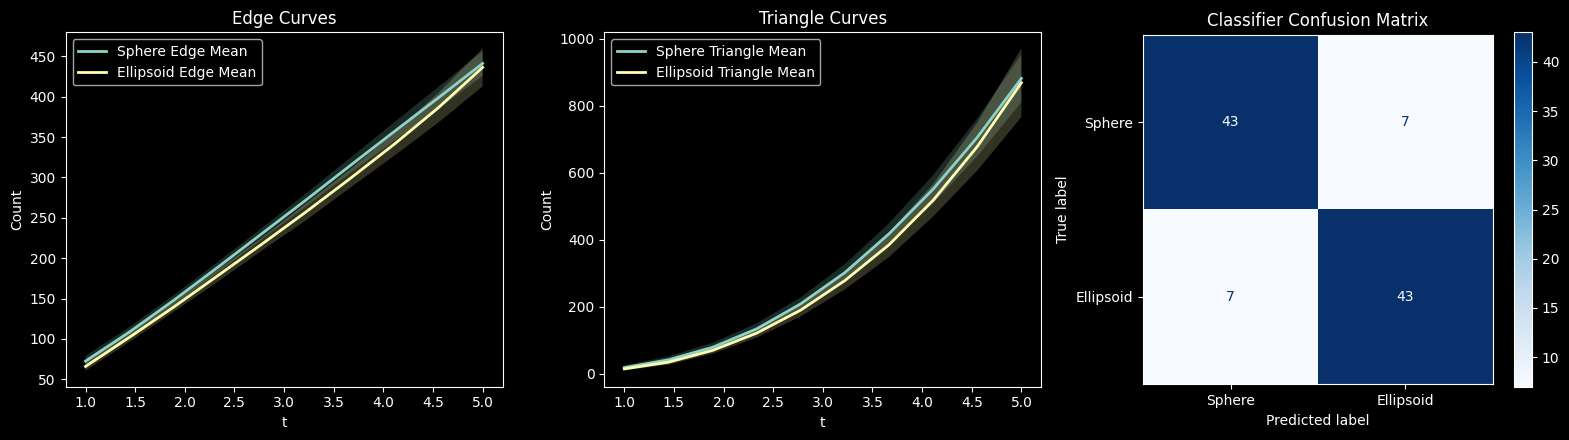

Accuracy: 0.86
Ambient dim: 2
Sphere radius: 2.23606797749979
Ellipsoid axes: [1. 5.]


In [9]:
plt.style.use("dark_background")

# INPUT
n_points = 100
n_resamples = 200
ambient_dim = 2
h = 0.2
t_grid = np.linspace(1,5,10)

ellipsoid_stretch = [1.0, 5.0]

result = sphere_vs_ellipsoid_concat_curve_classifier_kde(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    h = h,
    ellipsoid_stretch=ellipsoid_stretch,
)

fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", non_unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_sphere_ellipsoid_concat_results(result)


This notebook tests whether **concatenating KDE-weighted edge-count curves and KDE-weighted triangle-count curves** improves classification between a sphere and an ellipsoid.

The main idea is to use **two topological summaries at once**:
- an **edge curve**, which counts how many graph edges appear as the threshold `t` increases
- a **triangle curve**, which counts how many triangles appear as `t` increases

For each simulated point cloud, these two curves are concatenated into one longer feature vector and used as input to a classifier.

## Main workflow

The function `sphere_vs_ellipsoid_concat_curve_classifier_kde(...)` does the following:

1. Generates many random point clouds from a sphere and many from an ellipsoid.
2. Chooses the sphere radius so the sphere and ellipsoid have the same target volume.
3. Computes a **KDE-weighted edge-count curve** for each sample.
4. Computes a **KDE-weighted triangle-count curve** for each sample.
5. Concatenates the two curves side by side using `np.hstack(...)`.
6. Uses the concatenated curves as feature vectors in a `StandardScaler + LogisticRegression` classifier.
7. Splits the data into training and test sets and evaluates classification accuracy.

## What the concatenation means

If `t_grid` has length 10, then:
- each edge curve has length 10
- each triangle curve has length 10
- the concatenated feature vector has length 20

So each row of the final data matrix contains:

- the first 10 entries: edge-count information
- the next 10 entries: triangle-count information

This is meant to capture more geometric information than using edge counts alone.

## What this run is using

The current experiment uses:

- `ambient_dim = 2`
- `n_points = 100`
- `n_resamples = 200` per class
- `t_grid = np.linspace(1, 2, 10)`
- `h = 0.2`
- `ellipsoid_stretch = [1.0, 5.0]`

So this is a **2D circle vs ellipse** problem, with both edge and triangle summaries included.

## What the plots show

The notebook produces two main displays:

1. A sample figure showing one sphere point cloud and one ellipsoid point cloud.
2. A results figure with:
   - the mean edge curves for sphere vs ellipsoid
   - the mean triangle curves for sphere vs ellipsoid
   - the confusion matrix of the classifier

The plotting function splits the concatenated feature vectors back into:
- edge features
- triangle features

so they can be visualized separately.

## Current result

The stored output shows:

- **Accuracy: 0.82**
- Sphere precision/recall/F1: **0.82 / 0.82 / 0.82**
- Ellipsoid precision/recall/F1: **0.82 / 0.82 / 0.82**
- Test set size: **100 curves total**
  50 sphere samples and 50 ellipsoid samples

This means the classifier correctly labeled about **82 out of 100** held-out samples.

## Interpretation

The concatenated edge+triangle features do separate the two classes reasonably well, so both summaries contain useful geometric information.

On this run the concatenated classifier achieves **0.82 accuracy**, which is higher than the kde edge classifier on the same settings (**0.8 accuracy**)